n   Trials   Truly balanced   Classified BALANCED
2   25       25               25/25
3   25       25               25/25
4   25       25               25/25
5   25       25               25/25
Inputs mapped to 1: ['000', '001', '011', '101']


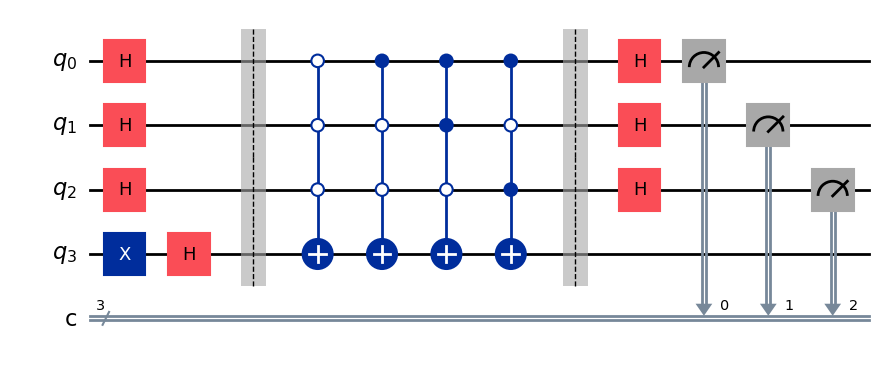

Counts: {'111': 243, '010': 271, '100': 246, '001': 240}


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import MCXGate
from qiskit_aer import AerSimulator
def random_balanced_oracle(n):
    inputs = list(range(2 ** n))
    ones = set(random.sample(inputs, 2 ** (n- 1))) # exactly half of the inputs map to 1
    oracle = QuantumCircuit(n + 1, name="random-balanced")
    for x in sorted(ones):
        # flip the ancilla only when the input register equals x
        oracle.append(MCXGate(n, ctrl_state=x), list(range(n + 1)))
    return oracle, ones
def dj_with_oracle(n, oracle):
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.barrier()
    qc.compose(oracle, inplace=True)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc
random.seed(2026)
sim = AerSimulator()
trials = 25
print(f"{'n':<4}{'Trials':<9}{'Truly balanced':<17}{'Classified BALANCED'}")
for n in range(2, 6):
    balanced_ok = classified_ok = 0
    for _ in range(trials):
        oracle, ones = random_balanced_oracle(n)
        balanced_ok += (len(ones) == 2 ** (n- 1))
        qc = transpile(dj_with_oracle(n, oracle), sim)
        counts = sim.run(qc, shots=200).result().get_counts()
        classified_ok += (counts.get('0' * n, 0) == 0) # all-zeros never appears if balanced
    print(f"{n:<4}{trials:<9}{balanced_ok:<17}{classified_ok}/{trials}")
# Example: one random balanced oracle for n = 3
random.seed(7)
oracle, ones = random_balanced_oracle(3)
print("Inputs mapped to 1:", sorted(format(x, '03b') for x in ones))
qc = dj_with_oracle(3, oracle)
display(qc.draw(output='mpl', style='iqp'))
print("Counts:", sim.run(transpile(qc, sim), shots=1000).result().get_counts())
